# Model 1 — Improved: Predicting Person-Days Generated
### Changes from original:
- Removed `avg_wage_per_day` (policy constant — causes near-mathematical leakage)
- Added `year` as **categorical** (one-hot encoded) instead of numeric
- Added `district` as one-hot encoded (captures structural district-level efficiency)
- Used **5-Fold Cross Validation** instead of single 80/20 split for honest evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
df = pd.read_csv('D:/sem4/DWDM/Datasets/clean_mgnrega_dataset.csv')
df = df[df['exp_unskilled_wage'] > 0].copy()
print(df.shape)
print(df["year"].unique())
df.head()


(182, 19)
[2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


,district,exp_unskilled_wage,prev_wage_liability,exp_material,prev_material_liability,admin_exp,prev_admin_liability,total_exp_without_liability,prev_total_liability,total_exp_with_liability,households_employed,persons_worked,persondays_generated,avg_days_per_household,avg_wage_per_day,works_completed,works_in_progress,cost_per_personday,year
2,ANANTAPUR,23481.23,2159.27,15642.47,55.06,3164.52,0.0,42288.22,2214.33,44502.56,278974,489229,17318105,62.08,161.81,134357,90797,270.74,2016
5,CHITTOOR,19306.15,282.75,9984.97,10.77,3027.83,0.0,32318.94,293.52,32612.46,238092,377486,13218795,55.52,165.89,145007,55605,264.38,2016
6,EAST GODAVARI,22732.82,901.36,14547.31,23.39,3589.72,0.0,40869.85,924.75,41794.60,393963,588396,16504722,41.89,156.26,105003,103241,266.30,2016
8,GUNTUR,11571.98,304.25,6791.21,19.31,2266.53,0.0,20629.72,323.56,20953.28,328144,522575,8370995,25.51,148.71,104882,56243,257.07,2016
11,KRISHNA,9578.76,462.08,6535.50,7.43,1616.29,0.0,17730.56,469.51,18200.08,228690,382340,7699601,33.67,137.44,46948,28590,243.40,2016


## Step 1: One-hot encode `year` and `district` (both categorical)

In [3]:
# Treat year as categorical before encoding
df['year'] = df['year'].astype(str)

df_encoded = pd.get_dummies(df, columns=['year', 'district'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (182, 51)


,exp_unskilled_wage,prev_wage_liability,exp_material,prev_material_liability,admin_exp,prev_admin_liability,total_exp_without_liability,prev_total_liability,total_exp_with_liability,households_employed,...,district_PALNADU,district_PARVATHIPURAM MANYAM,district_PRAKASAM,district_SRI SATHYA SAI,district_SRIKAKULAM,district_TIRUPATI,district_VISAKHAPATANAM,district_VIZIANAGARAM,district_WEST GODAVARI,district_Y.S.R
2,23481.23,2159.27,15642.47,55.06,3164.52,0.0,42288.22,2214.33,44502.56,278974,...,False,False,False,False,False,False,False,False,False,False
5,19306.15,282.75,9984.97,10.77,3027.83,0.0,32318.94,293.52,32612.46,238092,...,False,False,False,False,False,False,False,False,False,False
6,22732.82,901.36,14547.31,23.39,3589.72,0.0,40869.85,924.75,41794.60,393963,...,False,False,False,False,False,False,False,False,False,False
8,11571.98,304.25,6791.21,19.31,2266.53,0.0,20629.72,323.56,20953.28,328144,...,False,False,False,False,False,False,False,False,False,False
11,9578.76,462.08,6535.50,7.43,1616.29,0.0,17730.56,469.51,18200.08,228690,...,False,False,False,False,False,False,False,False,False,False


## Step 2: Define features and target
### Removed: `avg_wage_per_day` — it's a government-notified policy constant per year,
### nearly uniform across all districts. Including it creates a near-arithmetic leak:
### persondays ≈ exp_unskilled_wage / avg_wage_per_day

In [ ]:
# Base expenditure + work scope features
base_features = [
    "exp_unskilled_wage",
    "exp_material",
    "admin_exp",
    #"avg_wage_per_day"
]

# Add all year and district dummy columns
year_cols = [c for c in df_encoded.columns if c.startswith('year_')]
district_cols = [c for c in df_encoded.columns if c.startswith('district_')]

features = base_features + year_cols + district_cols
target = "persondays_generated"

X = df_encoded[features]
y = df_encoded[target]

print(f"Total features: {len(features)}")
print(f"Year dummies: {year_cols}")

Total features: 37
Year dummies: ['year_2017', 'year_2018', 'year_2019', 'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024', 'year_2025']


## Step 3: Train/Test Split + Model Training

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Single Split Results ===")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

=== Single Split Results ===
RMSE : 1,598,058.29
R²   : 0.9054


## Step 4: 5-Fold Cross Validation
### More honest than a single split — evaluates model across all 5 different splits of data

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
cv_rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print("=== 5-Fold Cross Validation Results ===")
print(f"R² per fold  : {[round(s, 4) for s in cv_r2_scores]}")
print(f"Mean R²      : {cv_r2_scores.mean():.4f}")
print(f"Std R²       : {cv_r2_scores.std():.4f}  ← lower is more stable")
print()
print(f"RMSE per fold: {[round(s, 2) for s in cv_rmse_scores]}")
print(f"Mean RMSE    : {cv_rmse_scores.mean():,.2f}")

=== 5-Fold Cross Validation Results ===
R² per fold  : [np.float64(0.9011), np.float64(0.9531), np.float64(0.8552), np.float64(0.9128), np.float64(0.9204)]
Mean R²      : 0.9085
Std R²       : 0.0318  ← lower is more stable

RMSE per fold: [np.float64(1634343.92), np.float64(1456784.7), np.float64(2216329.86), np.float64(2442574.03), np.float64(1704128.21)]
Mean RMSE    : 1,890,832.14


## Step 5: Compare Original vs Improved Model

In [19]:
# Original model (with avg_wage_per_day, year as numeric, no district)
original_features = [
    "exp_unskilled_wage", 
    "exp_material", 
    "admin_exp",
    "works_completed",
    "works_in_progress", 
    "avg_wage_per_day"
]

df_orig = pd.read_csv('D:/sem4/DWDM/Datasets/clean_mgnrega_dataset.csv')
X_orig = df_orig[original_features]
y_orig = df_orig[target]

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)
orig_model = RandomForestRegressor(n_estimators=200, random_state=42)
orig_model.fit(X_tr_o, y_tr_o)
orig_pred = orig_model.predict(X_te_o)

orig_r2 = r2_score(y_te_o, orig_pred)
orig_rmse = root_mean_squared_error(y_te_o, orig_pred)

orig_cv = cross_val_score(orig_model, X_orig, y_orig, cv=kf, scoring='r2')
new_cv  = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("============================================================")
print(f"{'Metric':<30} {'Original':>12} {'Improved':>12}")
print("============================================================")
print(f"{'Single Split R²':<30} {orig_r2:>12.4f} {r2:>12.4f}")
print(f"{'Single Split RMSE':<30} {orig_rmse:>12,.0f} {rmse:>12,.0f}")
print(f"{'CV Mean R²':<30} {orig_cv.mean():>12.4f} {new_cv.mean():>12.4f}")
print(f"{'CV Std R²':<30} {orig_cv.std():>12.4f} {new_cv.std():>12.4f}")
print("============================================================")

Metric                             Original     Improved
Single Split R²                      0.9812       0.9054
Single Split RMSE                   985,530    1,598,058
CV Mean R²                           0.9788       0.9085
CV Std R²                            0.0048       0.0318


## Step 6: Actual vs Predicted Plot

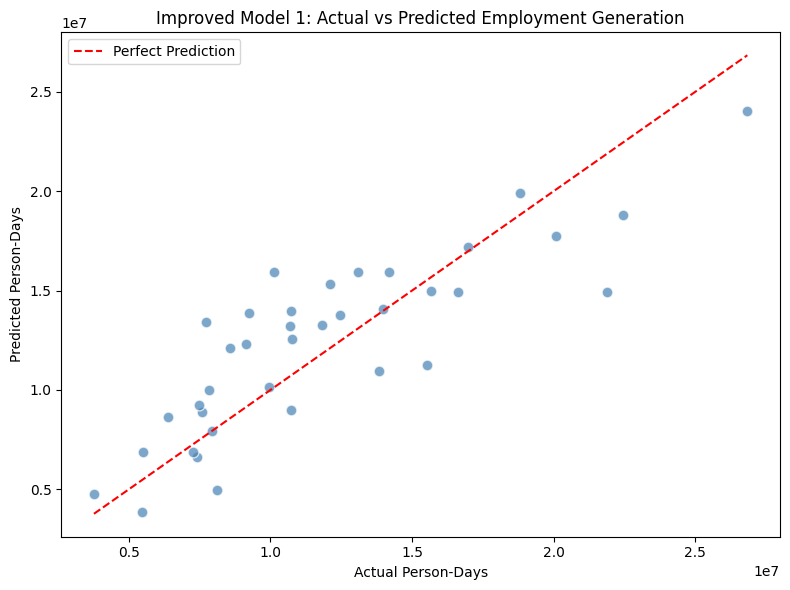

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', s=60)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Person-Days")
plt.ylabel("Predicted Person-Days")
plt.title("Improved Model 1: Actual vs Predicted Employment Generation")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Feature Importance

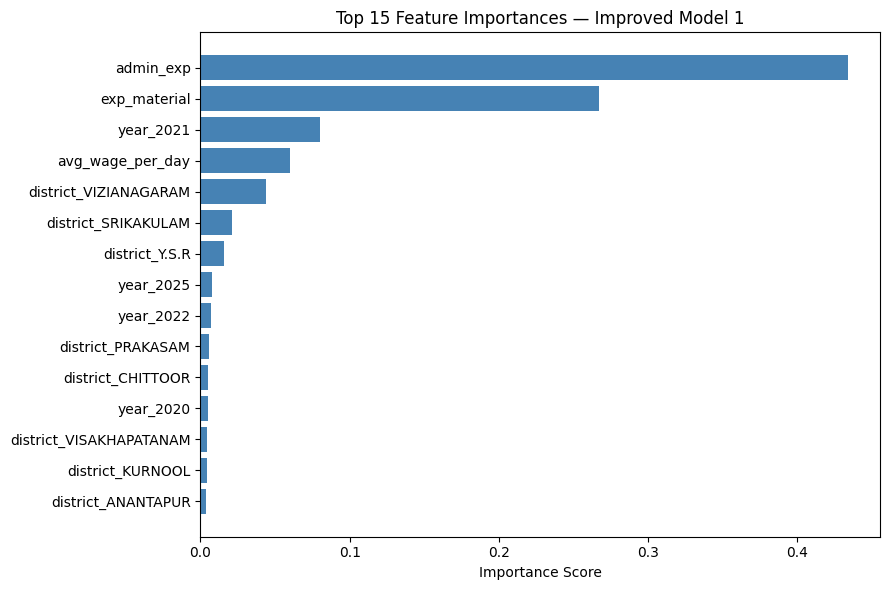


Top 10 features:
              feature  importance
            admin_exp    0.433599
         exp_material    0.267277
            year_2021    0.079900
     avg_wage_per_day    0.060104
district_VIZIANAGARAM    0.044001
  district_SRIKAKULAM    0.021085
       district_Y.S.R    0.016019
            year_2025    0.007880
            year_2022    0.006942
    district_PRAKASAM    0.006018


In [9]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Show top 15 features
top15 = importance_df.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances — Improved Model 1")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

## Step 8: District Efficiency — Persondays per Rupee Spent
### Policy insight: which districts generate the most employment per rupee allocated?

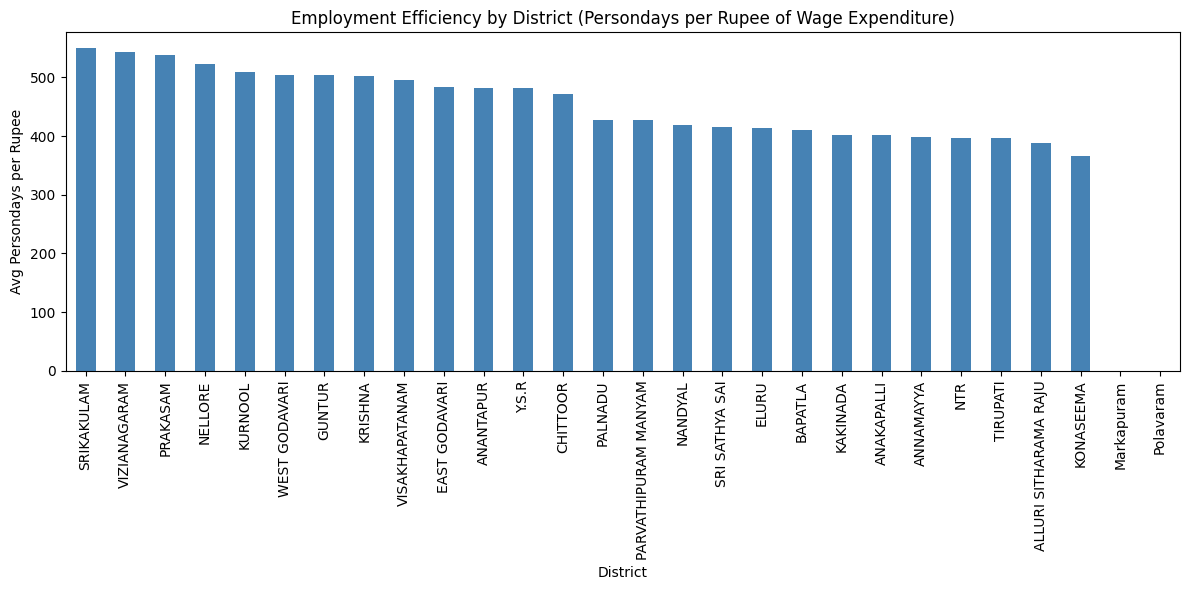


Top 5 most efficient districts:
district
SRIKAKULAM      549.163194
VIZIANAGARAM    542.449161
PRAKASAM        537.393080
NELLORE         522.870478
KURNOOL         509.439034
Name: efficiency, dtype: float64

Bottom 5 least efficient districts:
district
TIRUPATI                 396.404231
ALLURI SITHARAMA RAJU    388.773527
KONASEEMA                366.114152
Markapuram                      NaN
Polavaram                       NaN
Name: efficiency, dtype: float64


In [10]:
df_orig = pd.read_csv('D:/sem4/DWDM/Datasets/clean_mgnrega_dataset.csv')

df_orig['efficiency'] = df_orig['persondays_generated'] / df_orig['exp_unskilled_wage']

district_efficiency = df_orig.groupby('district')['efficiency'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
district_efficiency.plot(kind='bar', color='steelblue')
plt.xlabel("District")
plt.ylabel("Avg Persondays per Rupee")
plt.title("Employment Efficiency by District (Persondays per Rupee of Wage Expenditure)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 5 most efficient districts:")
print(district_efficiency.head())
print("\nBottom 5 least efficient districts:")
print(district_efficiency.tail())